In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("illinois_cleaned_county_data.csv")
df

,GradRate_Total,DropoutRate_Total,PerPupil_Federal,PerPupil_StateLocal,ELA_Proficiency,Math_Proficiency,Science_Proficiency,County_Clean,Median_Income
0,0.880000,0.061000,1757.251667,11029.023333,0.314818,0.274409,0.546800,ADAMS,64962.0
1,0.828000,0.029000,839.792000,12631.335000,0.324667,0.229000,0.523556,BOND,61603.0
2,0.864200,0.025600,1079.741667,14493.197222,0.245722,0.179222,0.457267,BOONE,81638.0
3,0.824667,0.056500,882.647500,15887.360000,0.312593,0.211037,0.542250,BUREAU,65894.0
4,0.906000,0.040000,1127.631000,12900.118000,0.428100,0.295500,0.600300,CARROLL,60871.0
...,...,...,...,...,...,...,...,...,...
79,0.876333,0.030500,1760.558919,13361.835405,0.367968,0.266097,0.588000,WHITESIDE,64536.0
80,0.915370,0.022789,1002.377796,15191.243978,0.385828,0.301310,0.541855,WILL,107799.0
81,0.852800,0.043600,2049.546154,10263.043462,0.387625,0.302542,0.564955,WILLIAMSON,65521.0
82,0.804824,0.047538,1667.015978,13640.608043,0.295256,0.225195,0.437605,WINNEBAGO,64363.0


In [3]:
df_train, df_test = train_test_split(df, test_size = 0.15, random_state = 207)

In [4]:
df_train

,GradRate_Total,DropoutRate_Total,PerPupil_Federal,PerPupil_StateLocal,ELA_Proficiency,Math_Proficiency,Science_Proficiency,County_Clean,Median_Income
14,0.892750,0.035250,1009.254583,14712.407917,0.306196,0.251391,0.534525,DEKALB,69022.0
25,0.938750,0.018000,683.517778,14938.768611,0.358794,0.282794,0.572143,GRUNDY,93060.0
5,0.887000,0.057000,2141.631818,11720.327273,0.250100,0.198300,0.505000,CASS,64907.0
4,0.906000,0.040000,1127.631000,12900.118000,0.428100,0.295500,0.600300,CARROLL,60871.0
36,0.913680,0.014348,1554.034561,14847.458830,0.311837,0.270482,0.516261,KANE,100678.0
...,...,...,...,...,...,...,...,...,...
78,0.771000,0.025000,1679.932143,10856.437857,0.327750,0.272333,0.549500,WHITE,53097.0
32,0.964000,0.035000,1357.606000,10593.354000,0.297750,0.251750,0.567750,JASPER,71094.0
53,0.912682,0.021857,878.754787,14905.705957,0.365782,0.285920,0.591568,MCHENRY,102836.0
50,0.872667,0.049000,1485.073846,12725.344615,0.268750,0.217333,0.501818,MASON,62127.0


In [5]:
df_test

,GradRate_Total,DropoutRate_Total,PerPupil_Federal,PerPupil_StateLocal,ELA_Proficiency,Math_Proficiency,Science_Proficiency,County_Clean,Median_Income
70,0.883000,0.041000,2147.820000,12231.780000,0.459286,0.362143,0.545143,STARK,62284.0
33,0.847000,0.027000,2600.963429,12002.629143,0.303971,0.194059,0.491857,JEFFERSON,61102.0
65,0.887000,0.051000,2181.665000,10396.840000,0.344000,0.262750,0.427500,RICHLAND,60404.0
40,0.919486,0.021581,900.919091,18222.727603,0.410076,0.352323,0.586350,LAKE,108917.0
81,0.852800,0.043600,2049.546154,10263.043462,0.387625,0.302542,0.564955,WILLIAMSON,65521.0
48,0.803833,0.049500,2470.782500,11895.076667,0.253143,0.163543,0.422645,MARION,60839.0
47,0.865200,0.042500,2045.685814,11862.914186,0.272145,0.233101,0.504754,MADISON,74800.0
27,0.838250,0.044000,1618.734500,12336.889500,0.283200,0.187000,0.531684,HANCOCK,65044.0
43,0.875833,0.053667,989.841667,17419.387778,0.257152,0.214242,0.489821,LIVINGSTON,70796.0
45,0.868333,0.050222,1510.556744,11399.710233,0.257750,0.171025,0.396846,MACON,62449.0


In [6]:
df.describe()

,GradRate_Total,DropoutRate_Total,PerPupil_Federal,PerPupil_StateLocal,ELA_Proficiency,Math_Proficiency,Science_Proficiency,Median_Income
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,0.863062,0.042252,1568.493915,12729.911201,0.321159,0.235722,0.541923,68687.821429
std,0.049798,0.016709,640.382841,1903.524109,0.071215,0.071303,0.067804,14236.830902
min,0.715500,0.014348,119.345000,9543.868667,0.125500,0.060250,0.396846,45572.000000
25%,0.836533,0.029750,1115.658667,11379.876879,0.272109,0.186797,0.494925,60687.500000
50%,0.868688,0.040250,1517.652250,12525.176000,0.308196,0.222598,0.543696,64950.000000
75%,0.894250,0.053167,1996.538348,13938.041317,0.364445,0.274461,0.591037,74132.000000
max,0.964000,0.102000,3562.996111,18222.727603,0.480947,0.436133,0.696923,110502.000000


## Visualizations

c:\Users\willi\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\willi\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\willi\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\willi\miniconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

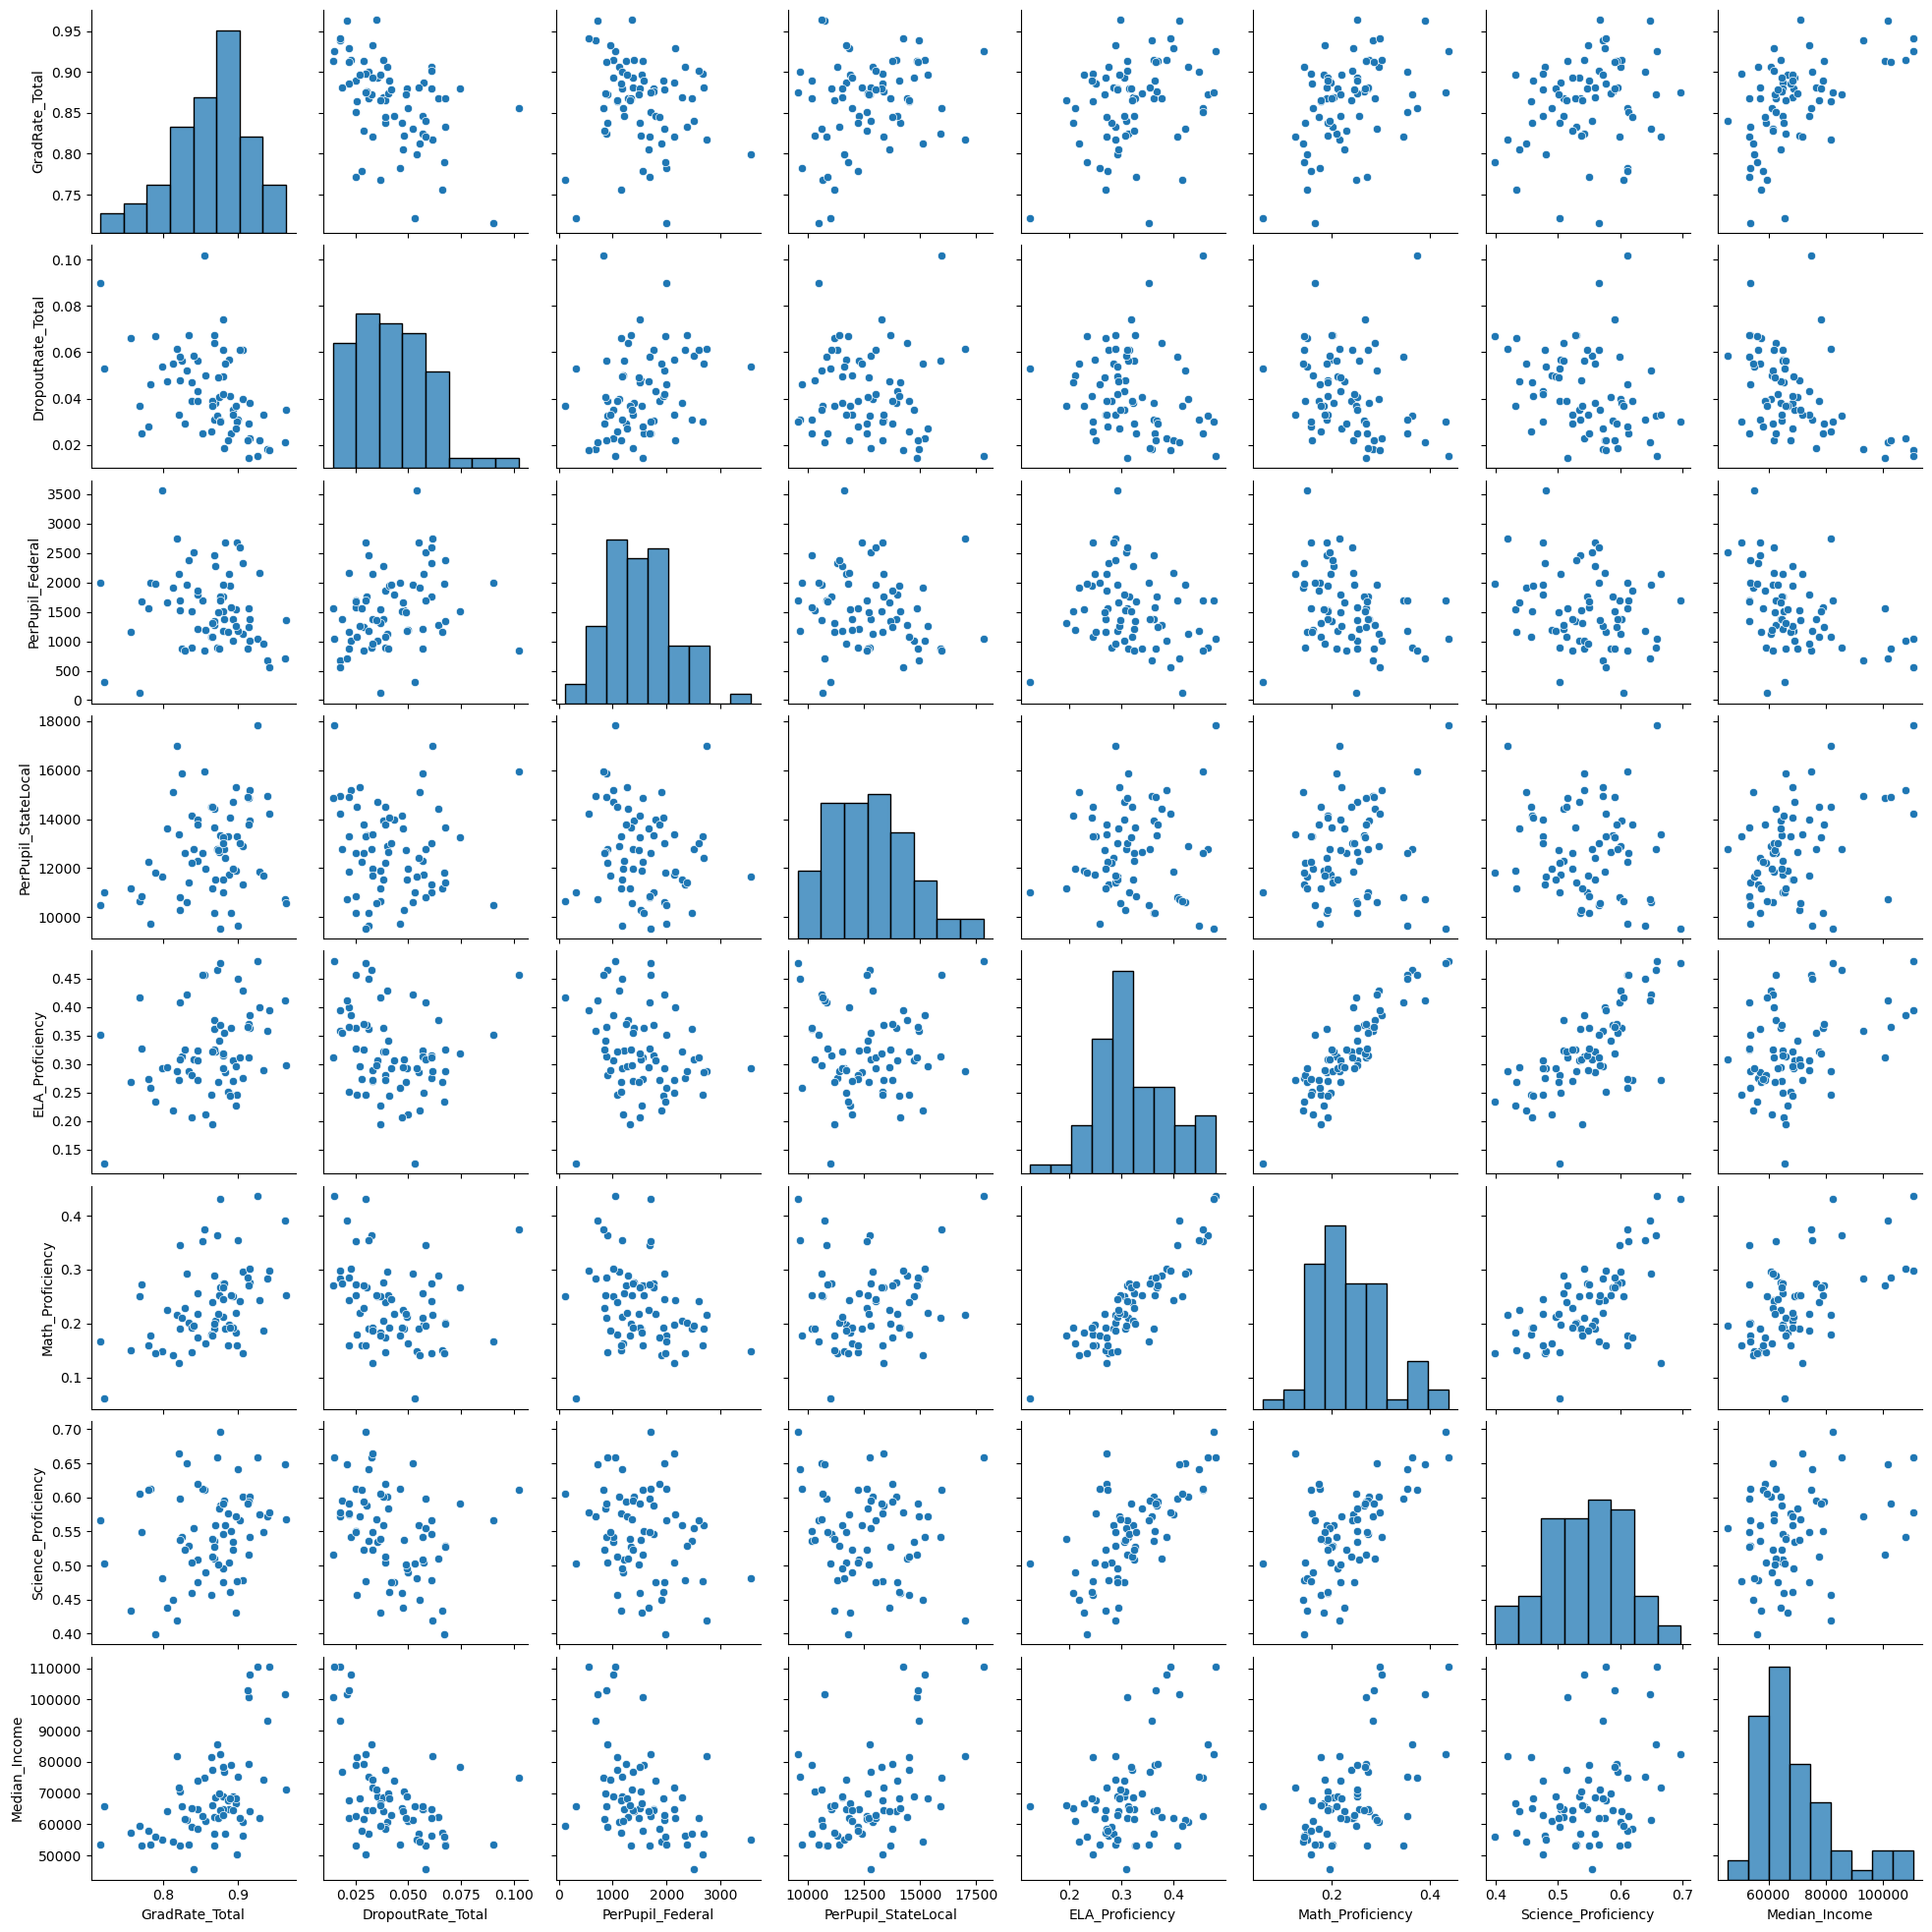

In [7]:
sns.pairplot(df_train[["GradRate_Total", "DropoutRate_Total", "PerPupil_Federal", "PerPupil_StateLocal", "ELA_Proficiency", "Math_Proficiency", "Science_Proficiency", "Median_Income"]])

,PerPupil_Federal,Median_Income
PerPupil_Federal,1.000000,-0.458569
Median_Income,-0.458569,1.000000


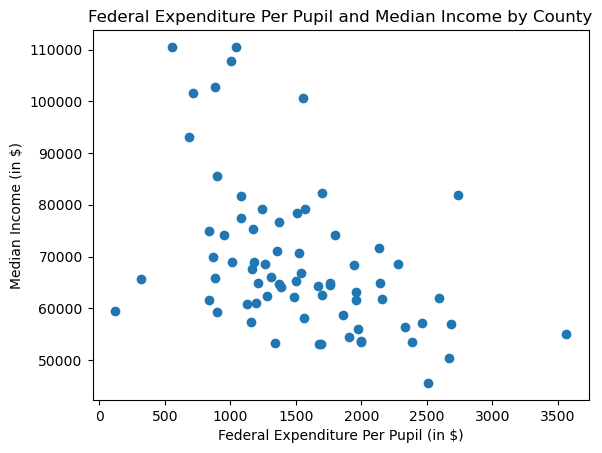

In [8]:
plt.scatter(df_train[["PerPupil_Federal"]], df_train[["Median_Income"]])
plt.xlabel("Federal Expenditure Per Pupil (in $)")
plt.ylabel("Median Income (in $)")
plt.title("Federal Expenditure Per Pupil and Median Income by County")
df_train[["PerPupil_Federal","Median_Income"]].corr()

,PerPupil_StateLocal,Median_Income
PerPupil_StateLocal,1.000000,0.415676
Median_Income,0.415676,1.000000


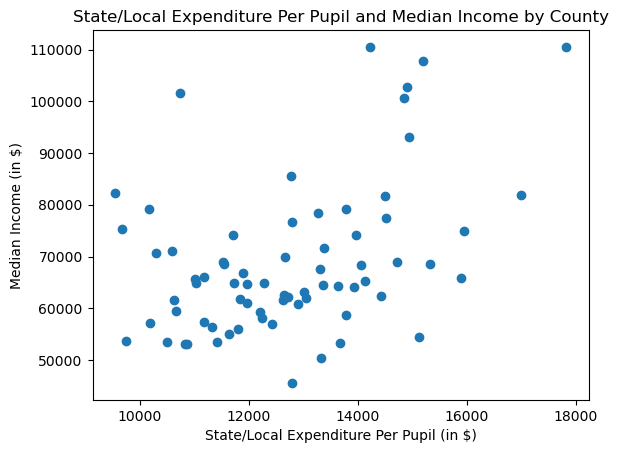

In [9]:
plt.scatter(df_train[["PerPupil_StateLocal"]], df_train[["Median_Income"]])
plt.xlabel("State/Local Expenditure Per Pupil (in $)")
plt.ylabel("Median Income (in $)")
plt.title("State/Local Expenditure Per Pupil and Median Income by County")
df_train[["PerPupil_StateLocal","Median_Income"]].corr()

,Math_Proficiency,Median_Income
Math_Proficiency,1.000000,0.545723
Median_Income,0.545723,1.000000


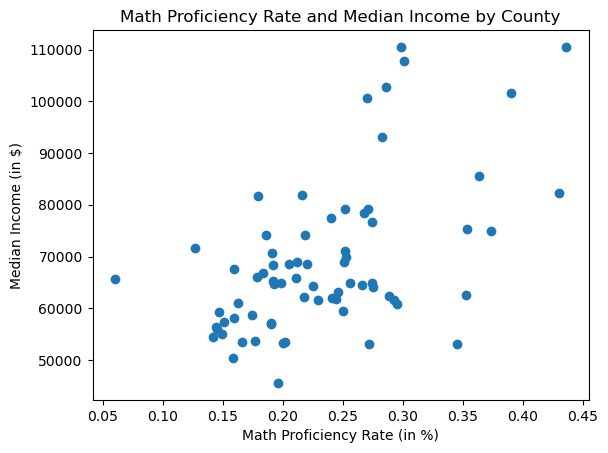

In [10]:
plt.scatter(df_train[["Math_Proficiency"]], df_train[["Median_Income"]])
plt.xlabel("Math Proficiency Rate (in %)")
plt.ylabel("Median Income (in $)")
plt.title("Math Proficiency Rate and Median Income by County")
df_train[["Math_Proficiency","Median_Income"]].corr()

,ELA_Proficiency,Median_Income
ELA_Proficiency,1.000000,0.387444
Median_Income,0.387444,1.000000


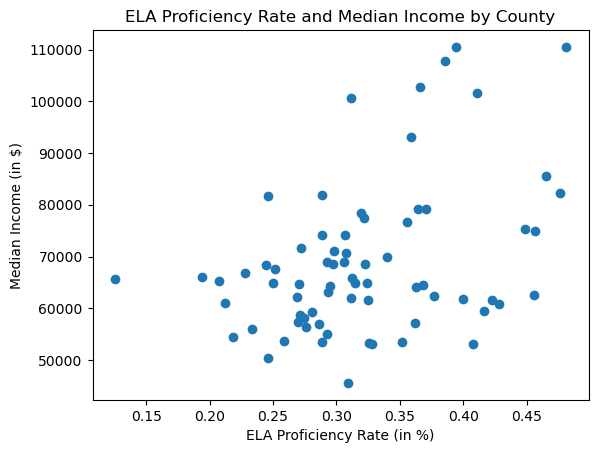

In [11]:
plt.scatter(df_train[["ELA_Proficiency"]], df_train[["Median_Income"]])
plt.xlabel("ELA Proficiency Rate (in %)")
plt.ylabel("Median Income (in $)")
plt.title("ELA Proficiency Rate and Median Income by County")
df_train[["ELA_Proficiency","Median_Income"]].corr()

,Science_Proficiency,Median_Income
Science_Proficiency,1.000000,0.280451
Median_Income,0.280451,1.000000


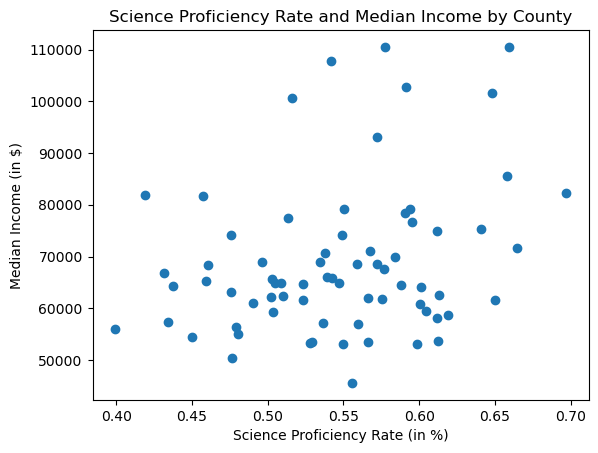

In [12]:
plt.scatter(df_train[["Science_Proficiency"]], df_train[["Median_Income"]])
plt.xlabel("Science Proficiency Rate (in %)")
plt.ylabel("Median Income (in $)")
plt.title("Science Proficiency Rate and Median Income by County")
df_train[["Science_Proficiency","Median_Income"]].corr()

## Regression Model

In [13]:
#Ordinary Least Squares Regression Model
model = smf.ols(formula = "Median_Income~GradRate_Total+DropoutRate_Total+PerPupil_Federal+PerPupil_StateLocal+Math_Proficiency+Science_Proficiency+ELA_Proficiency", data = df_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Median_Income   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     14.22
Date:                Tue, 09 Dec 2025   Prob (F-statistic):           6.43e-11
Time:                        18:36:49   Log-Likelihood:                -746.92
No. Observations:                  71   AIC:                             1510.
Df Residuals:                      63   BIC:                             1528.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            8521.8345   2.86e+04      0.298      0.766   -4.85e+04    6.56e+04
GradRate_Total       4.798e+04   2.84e+04      1.692      0.096   -8689.070    1.05e+05
DropoutRate_Total   -2.114e+05   7.72e+04     -2.740      0.008   -3.66e+05   -5.72e+04
PerPupil_Federal       -5.3243      1.992     -2.673      0.010      -9.305      -1.344
PerPupil_StateLocal     2.1055      0.685      3.073      0.003       0.736       3.475
Math_Proficiency     8.532e+04   3.75e+04      2.277      0.026    1.04e+04     1.6e+05
Science_Proficiency -4133.5151   2.55e+04     -0.162      0.872    -5.5e+04    4.68e+04
ELA_Proficiency      -2.62e+04   3.72e+04     -0.705      0.484      -1e+05    4.81e+04
==============================================================================
Omnibus:                        2.744   Durbin-Watson:                   2.330
Prob(Omnibus):                  0.254   Jarque-Bera (JB):                2.499
Skew:                           0.371   Prob(JB):                        0.287
Kurtosis:                       2.458   Cond. No.                     9.21e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.21e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [14]:
test = df_test["Median_Income"]
predtest = model.predict(df_test)
rmse = mean_squared_error(test, predtest, squared=False)
rmse

8020.686217029084

## Equation

Predicted Median Income = 8,521.8345 + 47,980(Graduation Rate) - 211,400(Dropout Rate) - 5.3242(PerPupil_Federal) + 2.0155(PerPupil_StateLocal) + 85,320(Math_Proficiency) - 4,133.5151(Science_Proficiency) - 26,200(ELA_Proficiency)